# Проект «Проверка гипотез в бизнесе»

* Автор: Путилина Елизавета
* Дата: 27.05.2026

Компания крупного сервиса проката самокатов GoFast предоставила три датасета с данными о пользователях сервиса, их поездках за один год, а также стоимости услуг в подписках. Необходимо проанализировать демографию пользователей и особенности использования самокатов, а также определить возможную выгоду от распространения платной подписки на самокаты.

### Цели и задачи проекта

**Цель проекта** - на основе предоставленных данных проанализировать поведение пользователей сервиса проката самокатов GoFast, выявить ключевые демографические и поведенческие паттерны, а затем с помощью статистических методов оценить, насколько выгодно для компании внедрять или масштабировать платную подписку.

**Задачи проекта:**
1. Загрузить данные и ознакомиться с ними;
2. Выполнить предобработку данных;
3. Провести исследовательский анализ данных;
4. Объединить данные;
5. Подсчитать выручку;
6. Проверить гипотезы;
7. Смоделировать распределения.

### Описание данных

Таблица с пользователями `users_go.csv`:
- `user_id` — уникальный идентификатор пользователя;
- `name` — имя пользователя;
- `age` — возраст;
- `city` — город;
- `subscription_type` — тип подписки: `free`, `ultra`.

Таблица с поездками `rides_go.csv`:
- `user_id` — уникальный идентификатор пользователя;
- `distance` — расстояние в метрах, которое пользователь проехал в текущей сессии;
- `duration` — продолжительность сессии в минутах, то есть время с того момента, как пользователь нажал кнопку «Начать поездку», до того, как он нажал кнопку «Завершить поездку»;
- `date` — дата совершения поездки.

Таблица с подписками `subscriptions_go.csv`:
- `subscription_type` — тип подписки;
- `minute_price` — стоимость одной минуты поездки по этой подписке;
- `start_ride_price` — стоимость начала поездки;
- `subscription_fee` — стоимость ежемесячного платежа.

### Содержимое проекта
1. [Загрузка данных](#chapter1)
2. [Знакомство с данными и их предварительная подготовка](#chapter2)
3. [Исследовательский анализ данных (EDA)](#chapter3)
4. [Объединение данных](#chapter4)
5. [Подсчёт выручки](#chapter5)
6. [Проверка гипотез](#chapter6)
7. [Распределения](#chapter7)

## 1. Загрузка данных<a class="anchor" id="chapter1"></a>

Загрузим все необходимые данные и ознакомимся с содержанием таблиц.

### 1.1 Импорт библиотеки pandas

Импортируем библиотеку `pandas`.

In [1]:
import pandas as pd

### 1.2 Чтение данных

Выгрузим и сохраним в отдельные датафреймы три CSV-файла:
- `/datasets/users_go.csv`;
- `/datasets/rides_go.csv`;
- `/datasets/subscriptions_go.csv`.

In [2]:
# Выгружаем данные
try:
    df_users_go = pd.read_csv('/datasets/users_go.csv')
    df_rides_go = pd.read_csv('/datasets/rides_go.csv')
    df_subscriptions_go = pd.read_csv('/datasets/subscriptions_go.csv')
    print('=' * 50)
    print('Данные успешно загружены.')
    print('=' * 50)
except Exception as e:
    print('=' * 50)
    print(f'Произошла ошибка при загрузке данных: {e}.')
    print('=' * 50)

Данные успешно загружены.


### 1.3 Печать первых строк

Выведем первые пять строк каждого датафрейма и ознакомимся с содержанием таблиц.

In [3]:
# Выведем первые строки каждого датафрейма
display(df_users_go.head(5))

display(df_rides_go.head(5))

display(df_subscriptions_go.head(5))

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


### 1.4 Подсчёт строк

Определим количество строк в каждом из трёх датафреймов. Это поможет оценить объём данных и выявить аномалии, например слишком малое количество записей.

In [4]:
print(df_users_go.shape[0], df_rides_go.shape[0], df_subscriptions_go.shape[0])

1565 18068 2


## 2. Знакомство с данными и их предварительная подготовка<a class="anchor" id="chapter2"></a>

Прежде чем начать анализ, важно убедиться в качестве предоставленных данных.

### 2.1 Определение типов данных

В датафрейме `df_rides_go` выведем типы данных каждой колонки стандартным атрибутом `dtypes`. Так мы проверим корректность типов и подготовим данные для дальнейшей обработки.

In [5]:
df_rides_go.dtypes

user_id       int64
distance    float64
duration    float64
date         object
dtype: object

### 2.2 Преобразование формата даты

Приведём столбец `date` в датафрейме `df_rides_go` к типу даты pandas, используя метод `pd.to_datetime()`.

In [6]:
df_rides_go['date'] = pd.to_datetime(df_rides_go['date'])

### 2.3 Создание столбца с месяцем

На основе столбца `date` создадим новый столбец `month`, содержащий номер месяца. Это нужно для последующей группировки данных и анализа сезонных трендов.

In [7]:
df_rides_go['month'] = df_rides_go['date'].dt.month

### 2.4 Поиск дублей и пропусков

* В датафрейме `df_users_go` определим количество пропусков и дубликатов.

In [8]:
# Количество пропусков
isna_count_df_users = df_users_go.isna().sum().sum()

# Количество дубликатов
duplicate_count_df_users = df_users_go.duplicated().sum()

# Вывод результатов
print(isna_count_df_users, duplicate_count_df_users)

0 31


В датасете `df_users_go`:
- Пропуски отсутствуют;
- Количество дубликатов - 31.

* В датафрейме `df_rides_go` определим количество пропусков и дубликатов.

In [9]:
# Количество пропусков
isna_count_df_rides = df_rides_go.isna().sum().sum()

# Количество дубликатов
duplicate_count_df_users = df_rides_go.duplicated().sum()

# Вывод результатов
print(isna_count_df_rides, duplicate_count_df_users)

0 0


В датасете `df_rides_go`:
- Пропуски отсутствуют;
- Дубликаты отсутствуют.

### 2.5 Заполнение пропусков и удаление дублей

Удалим все дубликаты в датасете `df_users_go`. Это шаг необходим для улучшения качества данных, что является ключевым для точного анализа.

In [10]:
df_users_go = df_users_go.drop_duplicates()

# Вывод результатов
print(duplicate_count_df_users)

0


### 2.6 Округление длительности поездки

В датафрейме поездок `df_rides_go` округлим время поездки `duration` до целого числа стандартным методом `round()`. Затем приведём эту колонку к целочисленному типу `int`. Этот шаг затем поможет нам правильно рассчитать прибыль, так как плата взимается только за целое число минут.

In [11]:
# Округлим длительность поездки
df_rides_go['duration'] = df_rides_go['duration'].round().astype('int')

## 3. Исследовательский анализ данных (EDA)<a class="anchor" id="chapter3"></a>

Исследовательский анализ данных — неотъемлемая часть работы аналитика. В этом задании изучим и визуализируем информацию о географии и демографии сервиса, а также, лучше найдём закономерности в дистанциях и длительности поездок.

### 3.1 Импорт библиотеки matplotlib

Импортируем библиотеку matplotlib.pyplot с сокращением `plt`.

In [12]:
import matplotlib.pyplot as plt

### 3.2 Количество пользователей по городам

Пользуясь данными из датафрейма `df_users_go`, изучим количество пользователей в каждом из городов. Создадим и выведим на экран объект `pd.Series`, названный `users_by_city_count`, с одной колонкой `count` — суммарным количеством пользователей в каждом городе `city`, отсортированным по убыванию.

In [13]:
users_by_city_count = df_users_go['city'].value_counts(ascending = False)

users_by_city_count

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64

### 3.3 Количество пользователей подписки

Создадим и выведим на экран серию `subscription_type_count` с количеством пользователей для каждого типа подписки `subscription_type`.

In [14]:
subscription_type_count = df_users_go['subscription_type'].value_counts()

subscription_type_count

free     835
ultra    699
Name: subscription_type, dtype: int64

### 3.4 Круговая диаграмма

Построим круговую диаграмму, указав процент пользователей с `free` и `ultra` подпиской. Вызовем метод `plot()` для серии `subscription_type_count` с указанием нужного аргумента для построения круговой диаграммы.

Затем добавим следующее:
- **Заголовок.** Установим заголовок с помощью параметра `title`, задав его как `'Соотношение пользователей с подпиской и без подписки'`.
- **Процентные метки.** Используем параметр `autopct='%.0f%%'` для отображения процентных значений на диаграмме. Достаточно передать аргумент в указанном виде методу `plot()`. Процентные метки часто хорошо дополняют круговые диаграммы.
- **Подпись оси Y.** Установим пустую строку для подписи оси Y `(ylabel='')`, чтобы она не отображалась.
- **Цвета секторов.** Используем параметр `colors`, задав красный цвет `red` для пользователей без подписки и зелёный `green` для подписчиков.

Затем вызовем `plt.show()` для отображения диаграммы.

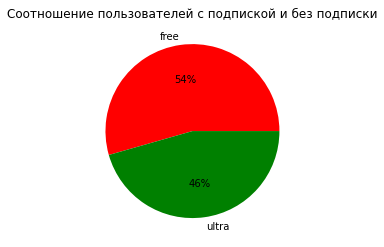

In [15]:
subscription_type_count.plot(
    kind = 'pie',
    title ='Соотношение пользователей с подпиской и без подписки',
    autopct = '%.0f%%',
    ylabel = '',
    colors = ['red', 'green']
)

plt.show()

### 3.5 Гистограмма возрастов

Построим гистограмму возрастов `age` пользователей самокатов. Используем количество бинов, равное разности максимального и минимального значений возраста.

Что нужно сделать:

1. Определить количество бинов `n_bins` как разницу между максимальным и минимальным значениями в столбце `age`.
2. Использовать метод `hist()` для столбца `df_users_go['age']`.
3. Установить количество бинов через параметр `bins=n_bins`.
4. Назначить заголовок графика как `'Возраст пользователей'` с помощью `plt.title()`.
5. Установить подпись оси X как `'Возраст'` с помощью `plt.xlabel()`.
6. Вызвать `plt.show()` для визуального отображения гистограммы.

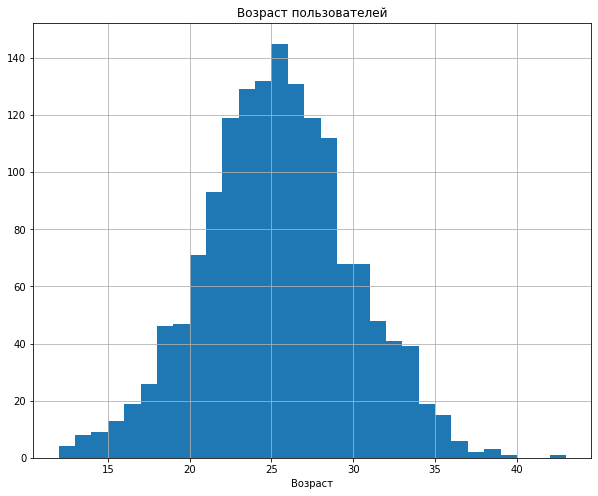

In [16]:
n_bins = df_users_go['age'].max() - df_users_go['age'].min()

plt.figure(figsize=(10, 8))

df_users_go['age'].hist(bins = n_bins)

plt.title('Возраст пользователей')

plt.xlabel('Возраст')

plt.show()

### 3.6 Несовершеннолетние пользователи

Рассчитаем долю несовершеннолетних (возрастом менее 18 лет) пользователей самокатов.

In [17]:
users_under_18_ratio = round(((df_users_go[df_users_go['age'] < 18].shape[0]) / df_users_go.shape[0]) * 100)

print(f'Доля несовершеннолетних пользователей самокатов составляет {users_under_18_ratio}%.')

Доля несовершеннолетних пользователей самокатов составляет 5%.


### 3.7 Характеристики длительности поездки

Длительность поездки является важной метрикой в работе сервиса проката самокатов. Если средняя длительность поездок будет слишком высокой, самокаты будут быстрее выходить из строя. Если слишком низкой, значит, клиентам что-то не нравится в сервисе.

В этом задании с помощью описательной статистики изучим длительность поездок:

1. Используйте колонку `duration` из датафрейма `df_rides_go`.
2. Расчитайте среднее значение и стандартное отклонение длительности поездки. Для расчёта стандартного отклонения можно воспользоваться методом `std()`.
3. Рассчитайте 25-й и 75-й процентили длительности поездки.
4. Выведите на экран ответ по предложенному шаблону.

Используя шаблон, сформулируем и выведите текстовый вывод о средней длительности поездки, а также о 25-м и 75-м процентилях длительности.

In [18]:
duration_mean = int(round(df_rides_go['duration'].mean()))
duration_std = int(round(df_rides_go['duration'].std()))

duration_pct25 = int(round(df_rides_go['duration'].quantile(0.25)))
duration_pct75 = int(round(df_rides_go['duration'].quantile(0.75)))

print(f'Средняя длительность поездки {duration_mean} минут со стандартным отклонением {duration_std}. Основная часть поездок занимает от {duration_pct25} до {duration_pct75} минут.')

Средняя длительность поездки 18 минут со стандартным отклонением 6. Основная часть поездок занимает от 14 до 22 минут.


## 4. Объединение данных<a class="anchor" id="chapter4"></a>

Объединим все данные в один датафрейм.

### 4.1 Объединение таблицы пользователей и поездок

Объединим датафреймы с информацией о пользователях `df_users_go` и поездках `df_rides_go`. Полученный датафрейм назовём просто `df`. При объединении используем метод `merge()` по общей для двух таблиц колонке и тип объединения `left`.

In [19]:
df = pd.merge(df_users_go, df_rides_go, how = 'left')

### 4.2 Присоединение информации о подписках

Присоединим к полученному датафрейму `df` информацию о подписках из `df_subscriptions_go`, используя метод `merge()` по общей колонке и тип объединения `left`.

In [20]:
df = pd.merge(df, df_subscriptions_go, on = 'subscription_type', how = 'left')

### 4.3. Размеры объединённого датафрейма

Для финальной проверки выведем на экран первые пять строк датафрейма, а также количество строк и столбцов полученного датафрейма `df`. Этот этап позволит убедиться, что никакие записи не потерялись при объединении.

In [21]:
# Выводим первые строки датафрейма
display(df.head(5))

# Выводим количество строк и столбцов в объединённом датафрейме
n_rows, n_cols = df.shape
print(f'В полученном датафрейме {n_rows} строк и {n_cols} столбцов.')

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8,6,0,199


В полученном датафрейме 18068 строк и 12 столбцов.


### 4.4 Отдельные датафреймы для пользователей с подпиской и без

Создадим два вспомогательных датафрейма на основе `df`: первый только для пользователей с подпиской `df_ultra` и второй только для пользователей без подписки `df_free`. В следующих заданиях два этих датафрейма пригодятся при изучении поведения пользователей с подпиской и без, а также при проверке продуктовых гипотез.

In [22]:
df_ultra = df[df['subscription_type'] == 'ultra']

df_free = df[df['subscription_type'] == 'free']

### 4.5 Гистограмма длительности поездок для обоих групп

На одном графике построим гистограмму распределения длительности поездок `duration` для пользователей с подпиской и без.

Что нужно сделать:

1. Установить размер графика: 15 по горизонтали и 5 по вертикали. Использовать `plt.figure(figsize=(15, 5))`.
2. Отобразить данные из столбца `duration` датафрейма `df_free` с помощью метода `hist()`, задав количество бинов `bins=30` и метку `label='free'`.
3. Отобразить данные из столбца `duration` датафрейма `df_ultra` с помощью метода `hist()`, также задав количество бинов `bins=30` и метку `label='ultra'`.
4. Установить подпись оси X как `'Длительность поездки, мин.'`, используя `plt.xlabel()`.
5. Задать заголовок графика как `'Гистограмма распределения длительности поездок'` методом `plt.title()`.
6. Добавить легенду для различения категорий на графике с использованием `plt.legend()`.
7. Вызвать `plt.show()` для показа графика пользователю.

Для удобства воспользуемся датафреймами, созданными на прошлом шаге, — `df_ultra` и `df_free`.

Дополнительно рассчитаем среднюю длительность поездки для пользователей с подпиской и без, округлив ее до целых стандартной функцией `round` и распечатаем на экран при помощи шаблона.

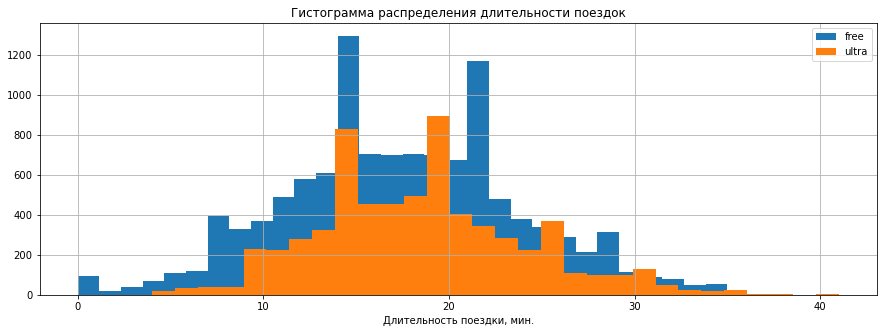

Средняя длительность поездки для пользователей без подписки 17 мин, а для пользователей с подпиской 19 мин


In [23]:
# Гистограмма длительности поездки для пользователей с подпиской и без
plt.figure(figsize=(15, 5))

df_free['duration'].hist(bins = 30, label = 'free')

df_ultra['duration'].hist(bins = 30, label = 'ultra')

plt.xlabel('Длительность поездки, мин.')

plt.title('Гистограмма распределения длительности поездок')

plt.legend()

plt.show()

# Расчет и вывод на экран средней длительности поездки для пользователей с подпиской и без
mean_duration_free = round(df_free['duration'].mean())
mean_duration_ultra = round(df_ultra['duration'].mean())
print(f'Средняя длительность поездки для пользователей без подписки {mean_duration_free} мин, а для пользователей с подпиской {mean_duration_ultra} мин')

## 5. Подсчёт выручки<a class="anchor" id="chapter5"></a>

Данные о количестве и длительности поездок объединены с ценами и тарифами, а значит, теперь есть всё необходимое, чтобы рассчитать важный для бизнеса показатель — выручку.

### 5.1 Данные сгруппированные по нужным колонкам

Сгруппируем данные по следующим столбцам: `user_id`, `name`, `subscription_type`, `month`. Группировку производим в датафрейме `df_gp`. В итоговом датафрейме `df_gp` должен сохраниться порядок агрегации изначальных столбцов и не должны использоваться групповые индексы (опция `as_index=False`).

In [24]:
df_gp = df.groupby(['user_id', 'name', 'subscription_type', 'month'], as_index = False)

### 5.2 Подсчёт агрегированных метрик

Создадим новый датафрейм `df_agg`. В нём для каждой группы рассчитаем и добавим в датафрейм следующие агрегированные значения, используя метод `agg()`:
- `total_distance` — сумма значений в столбце `distance`.
- `total_duration` — сумма значений в столбце `duration`.
- `rides_count` — количество элементов в столбце `duration`.
- `subscription_type` — первое значение в группе для столбца `subscription_type`.
- `minute_price` — первое значение в группе для столбца `minute_price`.
- `start_ride_price` — первое значение в группе для столбца `start_ride_price`.
- `subscription_fee` — первое значение в группе для столбца `subscription_fee`.

In [25]:
df_agg = df_gp.agg(
    total_distance = ('distance', 'sum'),
    total_duration = ('duration', 'sum'),
    rides_count = ('duration', 'count'),
    subscription_type = ('subscription_type', 'first'),
    minute_price = ('minute_price', 'first'),
    start_ride_price = ('start_ride_price', 'first'),
    subscription_fee = ('subscription_fee', 'first'),
)

### 5.3 Функция для подсчёта выручки

Создадим функцию `calculate_monthly_revenue(row)` для расчёта месячной выручки по формуле:

`monthly_revenue` = `start_ride_price` * `rides_count` + `minute_price` * `total_duration` + `subscription_fee`

В качестве входных данных функция будем принимать одну строку `row` датафрейма.

Здесь:
- `start_ride_price * rides_count` — выручка от начала каждой поездки.
- `minute_price * total_duration` — выручка за время использования.
- `subscription_fee` — фиксированная выручка от подписок.

In [26]:
def calculate_monthly_revenue(row):
    monthly_revenue = row['start_ride_price'] * row['rides_count'] + row['minute_price'] * row['total_duration'] + row['subscription_fee']
    return(monthly_revenue)

### 5.4 Создание столбца с месячной выручкой на пользователя

Создадим новый столбец с месячной выручкой на пользователя `monthly_revenue`. Для этого применим функцию `calculate_monthly_revenue(row)` к каждой строке агрегированного датафрейма `df_agg`.

In [27]:
df_agg['monthly_revenue'] = df_agg.apply(calculate_monthly_revenue,axis = 1)

### 5.5 Поиск пользователя с максимальной выручкой

Исследуем полученные значения выручки. Найдём пользователя с максимальной суммарной выручкой за весь период наблюдения и для него выведем на экран `user_id`, имя, месяц, количество поездок и выручку за каждый из месяцев.

In [28]:
user_total_revenue = df_agg.groupby('user_id').agg({'monthly_revenue' : 'sum'}).reset_index()

top_user_id = user_total_revenue.loc[user_total_revenue['monthly_revenue'].idxmax(), 'user_id']

top_user_data = df_agg[df_agg['user_id'] == top_user_id]

print(top_user_data[['user_id', 'name', 'month', 'rides_count', 'monthly_revenue']])

      user_id       name  month  rides_count  monthly_revenue
8877     1236  Александр      1            2              228
8878     1236  Александр      2            3              614
8879     1236  Александр      3            5              762
8880     1236  Александр      4            1              202
8881     1236  Александр      5            3              574
8882     1236  Александр      6            1              282
8883     1236  Александр      7            1              290
8884     1236  Александр      8            2              452
8885     1236  Александр      9            1              122
8886     1236  Александр     10            3              430
8887     1236  Александр     11            3              494
8888     1236  Александр     12            2              476


## 6. Проверка гипотез<a class="anchor" id="chapter6"></a>

### 6.1 Импорт библиотеки SciPy

Импортируем библиотеку `scipy.stats` с сокращением `st`.

In [29]:
import scipy.stats as st

### 6.2 Вспомогательная функция для интерпретации результатов

Напишем вспомогательную функцию `print_stattest_results(p_value, alpha)`, которая будет интерпретировать результаты статистического теста на основе p-value и заданного уровня значимости (α-уровня). Функция должна решать, следует ли принять альтернативную гипотезу или сохранить нулевую гипотезу.

У функции два параметра:
- `p_value` (тип `float`) — значение p-value, полученное в результате выполнения статистического теста.
- `alpha` (тип `float`, необязательный, по умолчанию `alpha = 0.05`) — уровень значимости статистического теста, который используется как порог для принятия решения об отклонении нулевой гипотезы.

Если мы принимаем альтернативную гипотезу, нужно вывести сообщение:
`'Полученное значение p_value=<Введённое значение p_value> меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.'`

Если мы не можем опровергнуть нулевую гипотезу, нужно вывести сообщение: `'Полученное значение p_value=<Введённое значение p_value> больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.'`

Вызовем функцию для `p_value = 0.0001` и `p_value = 0.1`.

In [30]:
def print_stattest_results(p_value:float, alpha:float = 0.05):
    if p_value < alpha:
        print(f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}. Принимаем альтернативную гипотезу.')
    else:
        print(f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}. Опровергнуть нулевую гипотезу нельзя.')

print_stattest_results(p_value=0.0001)
print_stattest_results(p_value=0.1)

Полученное значение p_value=0.0001 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Полученное значение p_value=0.1 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


### 6.3 Длительность для пользователей с подпиской и без

Важно понять, тратят ли пользователи с подпиской больше времени на поездки? Сформулируем нулевую и альтернативную гипотезы:
- Нулевая гипотеза (Н0): Среднее время поездки у пользователей с подпиской и без подписки одинаковое.
- Альтернативная гипотеза (Н1): Среднее время поездки у пользователей с подпиской больше, чем у пользователей без подписки.

Чтобы проверить эту гипотезу:
1. Используем неагрегированные данные из датафреймов `df_ultra` и `df_free`, созданные на одном из прошлых шагов.
2. Используем данные о продолжительности каждой поездки `duration` — отдельно для подписчиков и тех, у кого нет подписки.
3. Рассчитаем значение `p_value` для выбранной гипотезы, используя функции модуля `scipy.stats` и односторонний t-тест.
4. В качестве результата вызовем написанную функцию `print_stattest_results(p_value, alpha)`, передав ей рассчитанное значение `p_value`.
5. В конце дополнительно рассчитаем среднюю длительность поездки для тарифов `ultra` и `free`, округлив её до двух знаков после точки стандартной функцией `round()`.

In [31]:
ultra_duration = df_ultra['duration']
free_duration = df_free['duration']

results = st.ttest_ind(ultra_duration, free_duration, alternative= 'greater')

p_value = results.pvalue

print_stattest_results(p_value)

ultra_mean_duration = round(ultra_duration.mean(), 2)

free_mean_duration = round(free_duration.mean(), 2)

print(f'Средняя длительность поездки тарифа Ultra {ultra_mean_duration}')
print(f'Средняя длительность поездки тарифа Free {free_mean_duration}')

Полученное значение p_value=3.1600689435611813e-35 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя длительность поездки тарифа Ultra 18.55
Средняя длительность поездки тарифа Free 17.39


### 6.4 Длительность поездки: больше или меньше критического значения

Проанализируем ещё одну важную продуктовую гипотезу. Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что расстояние, которое проезжают пользователи с подпиской за одну поездку, меньше 3130 метров?

Сформулируем нулевую и альтернативную гипотезы:

- Нулевая гипотеза (Н0): Средняя дистанция поездки у пользователей с подпиской равна 3130 м.

- Альтернативная гипотеза (Н1): Средняя дистанция поездки у пользователей с подпиской больше 3130 м.

Чтобы проверить эту гипотезу:

1. Используем неагрегированные данные о каждой поездке пользователей с подпиской из датафрейма `df_ultra`.

2. Используем данные о дистанции каждой поездки `distance`.

3. Рассчитаем значение `p_value` для выбранной гипотезы, используя функции модуля `scipy.stats` и односторонний t-тест. Как применить эту функцию, если необходимо проверить равенство с одним значением?

4. В качестве результата вызовем написанную функцию `print_stattest_results(p_value, alpha)`, передав ей рассчитанное значение `p_value`.

In [32]:
null_hypothesis = 3130
ultra_distance = df_ultra['distance']

results = st.ttest_1samp(ultra_distance, null_hypothesis, alternative = 'greater')

p_value = results.pvalue

print_stattest_results(p_value)

Полученное значение p_value=0.9195368847849785 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


### 6.5 Прибыль от пользователей с подпиской и без

Проверим гипотезу о том, что выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки.

Сформулируем нулевую и альтернативную гипотезы:

- Нулевая гипотеза (Н0): Средняя месячная выручка у пользователей с подпиской и без подписки одинаковая.
- Альтернативная гипотеза (Н1): Средняя месячная выручка у пользователей с подпиской выше, чем у пользователей без подписки.

Чтобы проверить эту гипотезу:
1. Используем агрегированные данные из датафрейма `df_agg`, подготовленного на шаге 5.
2. Используем исходные данные о месячной выручке от каждого пользователя — `monthly_revenue`.
3. Рассчитаем значение `p_value` для выбранной гипотезы, используя функции модуля `scipy.stats` и односторонний t-тест.
4. В качестве результата вызовем написанную функцию `print_stattest_results(p_value, alpha)`, передав ей рассчитанное значение `p_value`.
5. Дополнительно рассчитаем среднюю выручку для тарифов `ultra` и `free`, округлив её до целого стандартной функцией `round()`.

In [33]:
revenue_ultra = df_agg[df_agg['subscription_type'] == 'ultra']['monthly_revenue']
revenue_free = df_agg[df_agg['subscription_type'] == 'free']['monthly_revenue']

results = st.ttest_ind(revenue_ultra, revenue_free, alternative = 'greater')

p_value = results.pvalue

print_stattest_results(p_value)

mean_revenue_ultra = round(revenue_ultra.mean())
mean_revenue_free = round(revenue_free.mean())

print(f'Средняя выручка подписчиков Ultra {mean_revenue_ultra} руб')
print(f'Средняя выручка подписчиков Free {mean_revenue_free} руб')

Полученное значение p_value=1.7274069878387966e-37 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя выручка подписчиков Ultra 359 руб
Средняя выручка подписчиков Free 322 руб


## 7. Распределения<a class="anchor" id="chapter7"></a>

В компании возникла идея предлагать дополнительную скидку подписчикам, совершающим длительные поездки продолжительностью более 30 минут. Вас просят оценить долю таких поездок.

В одном из предыдущих заданий вы уже построили гистограмму распределения длительности поездок для выборки. Однако эти данные охватывают лишь часть пользователей всех самокатов, а вас интересуют возможные значения для всей генеральной совокупности. Учитывая, что у вас нет доступа ко всем данным о поездках, было решено смоделировать длительность поездки с помощью нормального распределения, используя в качестве параметров выборочное среднее и стандартное отклонение из доступных данных о поездках.

### 7.1 Расчёт выборочного среднего и стандартного отклонения

1. Расчитаем среднюю длительность поездки и сохраним в переменную `mu`.
2. Вычислим стандартное отклонение длительности `duration` и сохраним в переменную `sigma`. Для вычисления стандартного отклонения можно применить метод `std()` к столбцу датасета.
3. Зададим значение переменной `target_time`, равное `30`. Эта переменная будет использоваться для последующего вычисления вероятности.
4. Выведем текстовый вывод по шаблону. При этом округлим оба значения до одного знака после точки стандартной функцией `round()`. Сами значения переменных должны остаться неимзменными для последующих задач.

In [34]:
# Вычисляем среднее значение
mu = df_ultra['duration'].mean()

# Вычисляем стандартное отклонение
sigma = df_ultra['duration'].std()

# Задаём целевое время
target_time = 30

# Делаем вывод
print(f'Средняя длительность поездки {round(mu, 1)}, стандартное отклонение {round(sigma, 1)}.')

Средняя длительность поездки 18.5, стандартное отклонение 5.6.


### 7.2 Вычисление значения функции распределения в точке (CDF)

Если вычислить значение функции распределения в точке, это позволит узнать вероятность того, что случайная величина примет значение меньше заданного либо равное ему. Соответственно, если мы хотим ответить на вопрос о вероятности поездки более 30 минут, потребуется использовать CDF.

1. Используем функцию `norm()` из библиотеки SciPy для создания нормального распределения с параметрами `mu` и `sigma`.

2. Применим метод `cdf()` к целевому времени `target_time` для получения вероятности того, что случайная величина будет меньше этого значения или равна ему. Полученное значение сохраним в переменную `prob`, округлив до трёх знаков после точки стандартной функцией `round()`.
3. Выведем на экран текстовый ответ по шаблону.

In [35]:
# Вычисляем вероятность того, что случайная величина будет меньше указанного значения или равна ему

duration_norm_dist  = st.norm(mu, sigma)

cdf_value = duration_norm_dist.cdf(target_time)

prob = round((1 - cdf_value), 3) # Используем CDF для нахождения накопленной вероятности

print(f'Вероятность поездки более 30 минут {prob}')

Вероятность поездки более 30 минут 0.02


### 7.3 Вероятность для интервала (CDF)

Коллеги посчитали, что процент пользователей, для которых будет показана скидка, недостаточно большой и вряд ли поможет в увеличении лояльности клиентов. Дополнительно вас просят проверить, какой процент пользователей совершает поездки в интервале от 20 до 30 минут. Возможно, именно для них стоит провести промоакцию?

Для этого:

1. Создадим переменные `low` и `high`, указывающие на начало и конец интересующего временного интервала. В этом случае они равны 20 и 30 минут.
2. Используем кумулятивную функцию распределения (CDF) для объекта `duration_norm_dist`, чтобы вычислить вероятность достижения верхней границы (`high`) и нижней границы (`low`).
3. Вычислим вероятность попадания в интервал, округлите до трёх знаков после точки стандартной функцией `round()` и сохраним в переменную `prob_interval`.
4. Выведем ответ, используя шаблон.

In [36]:
# Определяем границы интервала
low = 20
high = 30

cdf_low = duration_norm_dist.cdf(low)

cdf_high = duration_norm_dist.cdf(high)

# Вычисляем вероятность попадания в интервал
prob_interval = round(cdf_high - cdf_low, 3)

# Выводим результат
print(f'Вероятность того, что пользователь совершит поездку длительностью от {low} до {high} минут: {prob_interval}')

Вероятность того, что пользователь совершит поездку длительностью от 20 до 30 минут: 0.377


### 7.4 Определение критической дистанции поездок (PPF)

Длительные поездки могут негативно сказываться на сроке службы самоката. В связи с этим принято решение установить критическую дистанцию, превышение которой будет сопровождаться дополнительной платой. Для этого необходимо определить расстояние, которое превышается только в 10% поездок (90-й процентиль).

Ваша задача — смоделировать распределение длительности поездок, предполагая, что оно подчиняется нормальному закону, и рассчитать критическую дистанцию, ниже которой находится 90% всех поездок.

Для этого:
1. Рассчитаем среднюю дистанцию поездки для всех пользователей из датафрейма `df` (с подпиской и без) и сохраним в переменную `mu`.
2. Вычислим стандартное отклонение дистанции поездки `distance` и сохраним в переменную `sigma`. Для вычисления стандартного отклонения можно применить метод `std()` к столбцу датасета.
3. Зададим значение переменной `target_prob`, равное `0.90`. Эта переменная будет использоваться для последующего вычисления критической дистанции.
4. Создадим объект нормального распределения `distance_norm` с заданными значениями `mu` и `sigma`.
5. Применим к созданному нормальному распределению `distance_norm` метод `ppf()` и в качестве аргумента передайте целевую вероятность `target_prob`. Полученное значение сохраним в переменную `critical_distance`.
6. Выведем ответ, используя шаблон.

In [37]:
# Вычисляем среднее значение
mu = df['distance'].mean()

# Вычисляем стандартное отклонение
sigma = df['distance'].std()

# Вероятность, для которой хотим найти значение (90% случаев)
target_prob = 0.9

# Создаём объект нормального распределения
distance_norm = st.norm(mu, sigma)

# Рассчитываем критическую дистанцию для заданного процентиля поездок
critical_distance = distance_norm.ppf(target_prob)

print(f'{100 * target_prob} % поездок имеют дистанцию ниже критического значения {critical_distance:.2f} М.')

90.0 % поездок имеют дистанцию ниже критического значения 4501.94 М.


**ВЫВОДЫ**

* **География и аудитория.** Пользователи распределены по городам довольно равномерно, без явного доминирования одного города. Основная аудитория — молодые люди 20–30 лет, доля несовершеннолетних небольшая (5 %). Это говорит о том, что сервис популярен среди активной молодёжи в разных регионах;
* **Поведение пользователей.** Средняя поездка длится 18 минут, большинство укладываются в диапазон 14–22 минуты. Вероятность очень долгой поездки (более 30 минут) низкая — всего 2 %. При этом пользователи с подпиской катаются чуть дольше, чем те, кто без подписки (19 минут против 17);
* **Эффективность подписки.** Статистически подтверждено, что подписка влияет на поведение и выручку:
    * пользователи с подпиской совершают поездки в среднем дольше;
    * месячная выручка от подписчиков выше, чем от пользователей без подписки (359 руб. против 322 руб.);
    * разница в выручке и длительности поездок статистически значима (p‑value сильно меньше 0,05).
* **Дистанция поездок.** Нет оснований утверждать, что средняя дистанция поездки у подписчиков больше 3130 м (p‑value = 0,92, нулевую гипотезу не отвергаем). То есть подписка не приводит к тому, что люди начинают ездить существенно дальше.
* **Распределение поездок.** 90 % поездок короче 4502 м. Это хороший ориентир для понимания типичной длины маршрута.

**РЕКОМЕНДАЦИИ ДЛЯ БИЗНЕСА**

* **Развивать и продвигать подписку.** Поскольку подписчики приносят больше выручки и катаются дольше, стоит сделать подписку более привлекательной: например, добавить бонусы, скидки или эксклюзивные функции. Можно протестировать разные ценовые модели, чтобы увеличить долю подписчиков;
* **Фокусироваться на молодой аудитории.** Учитывая, что основная аудитория — люди 20–30 лет, рекламные и маркетинговые кампании стоит ориентировать именно на эту группу. Можно использовать каналы, популярные среди молодёжи (соцсети, мессенджеры, партнёрства с молодёжными брендами);
* **Учитывать типичную длительность поездки.** Поскольку большинство поездок укладываются в 20–22 минуты, а вероятность очень долгой поездки мала, можно оптимизировать парк самокатов и их зарядку под эти сценарии. Например, планировать маршруты и точки подзарядки с учётом средней длительности и дистанции;
* **Не рассчитывать на увеличение дистанции поездок за счёт подписки.** Поскольку подписка не влияет на длину поездки, не стоит строить маркетинговые предложения вокруг «путешествий на большие расстояния». Лучше акцентировать внимание на удобстве, экономии и дополнительных преимуществах подписки;
* **Использовать квантили для планирования.** Знание того, что 90 % поездок короче 4502 м, поможет в логистике и размещении станций: можно оптимизировать плотность станций и их расположение, чтобы покрывать наиболее популярные маршруты.